# Gene-level - Deconvolved Chromatin Analysis

- Focus on chromatin dynamics related to genes
- Linkage to expression, save for later.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
from pipeline.genelevel_chromatin_analysis import GeneChromatinAnalysis

# Test running the script to create plots from start to finish

output_directory = 'output/prototype_pipeline_subset'

# Create analysis object
analyzer = GeneChromatinAnalysis(output_directory)

# Initialize analyses
analyzer.initialize_analyses()

# Create and process datasets
analyzer.create_polar_datasets()

Initializing chromatin analysis... copy correction: True
Loading configs from replication runs:  output/prototype_pipeline_subset/single_replication/
Shifting mu0, gamma1, and gamma2, for alpha...
Creating directory: output/prototype_pipeline_subset/chromatin_analysis/...Directory exists. Skipping.
Loading data directory: output/prototype_pipeline_subset/chromatin_deconvolution/deconvolution_data
Copy correction: True
Will save chromatin measures to: output/prototype_pipeline_subset/chromatin_analysis/Loading precomputed chromatin measures
Initializing genome deconvolution analysis...
All analyses initialized successfully
Creating polar datasets...
Filtered to 5578 common ORFs across all datasets
Polar datasets created successfully


Plotting PTR sensitivity analysis...
Interesting threshold values:
0.8256, 0.6611: p-value 7.39
0.7433, 0.7433: p-value 7.63
0.8256, 0.7433: p-value 8.55
0.9078, 0.7433: p-value 7.40
Highest p-value: 0.8256, 0.7433: p-value 8.55
PTR sensitivity plots saved


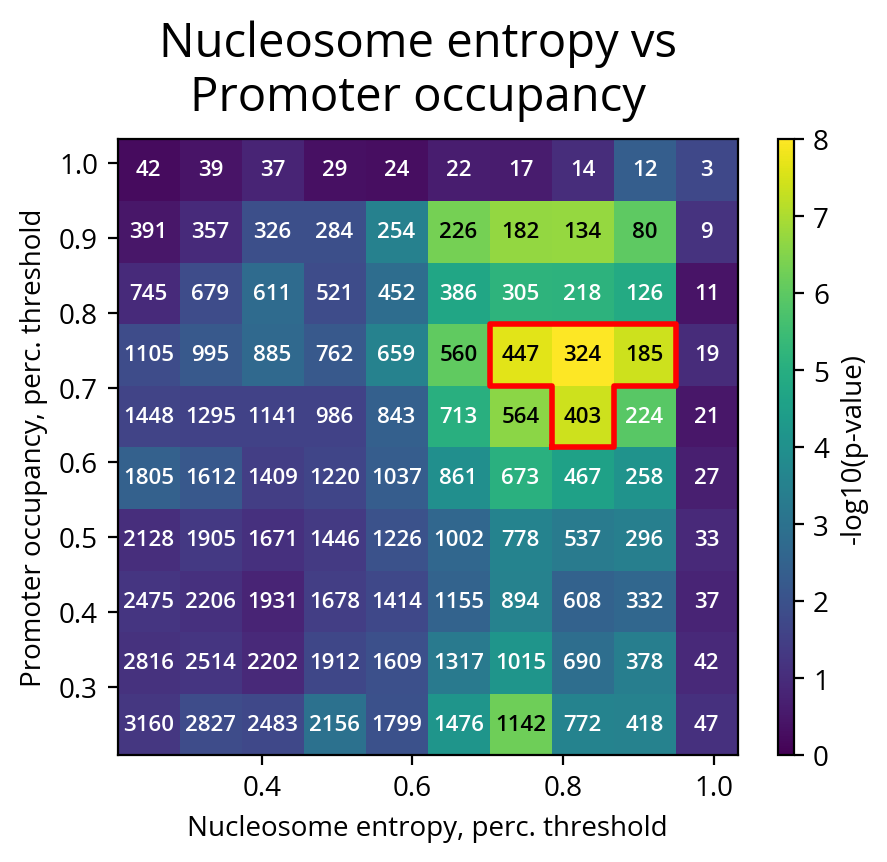

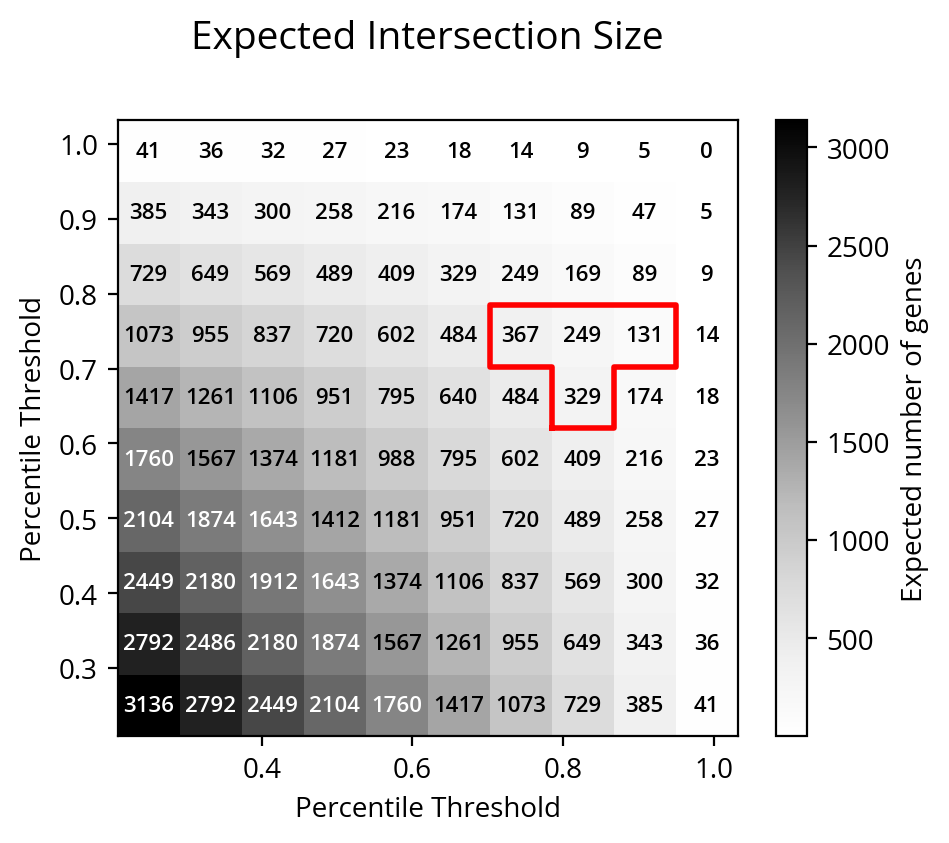

In [211]:
analyzer.plot_ptr_sensitivity()

Plotting PTR distributions...
PTR distribution plots saved


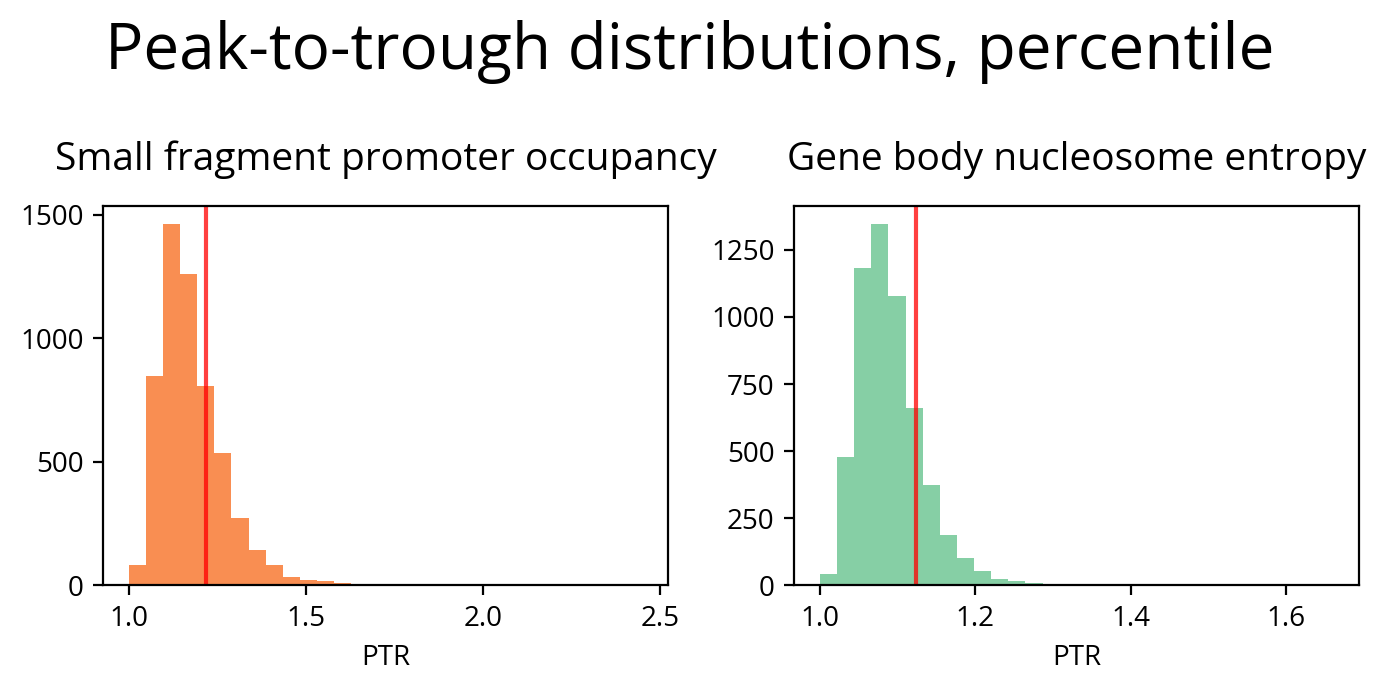

In [137]:
analyzer.plot_ptr_distributions()

Plotting polar branches...
Polar branch plots saved


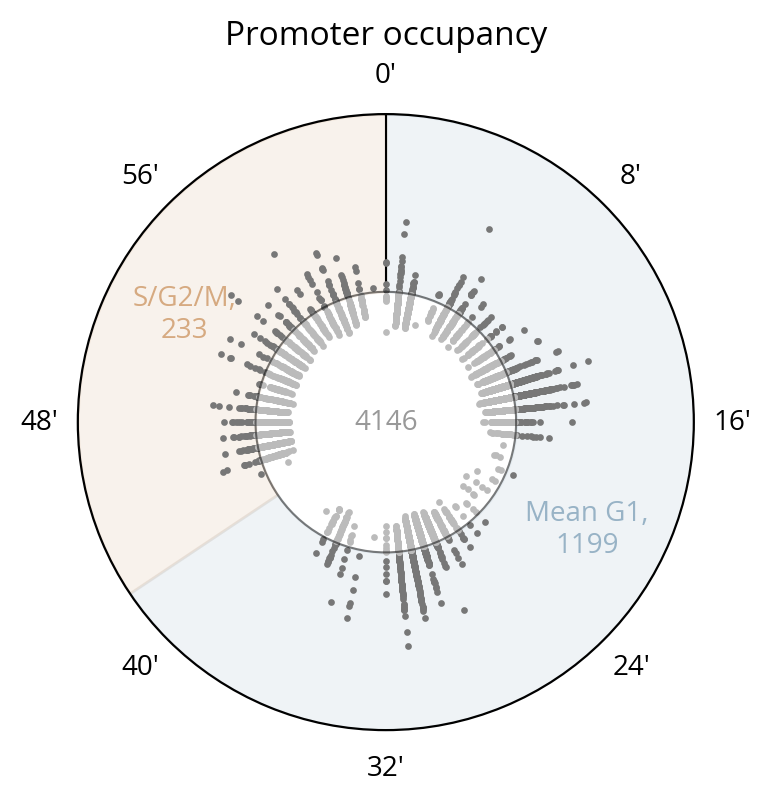

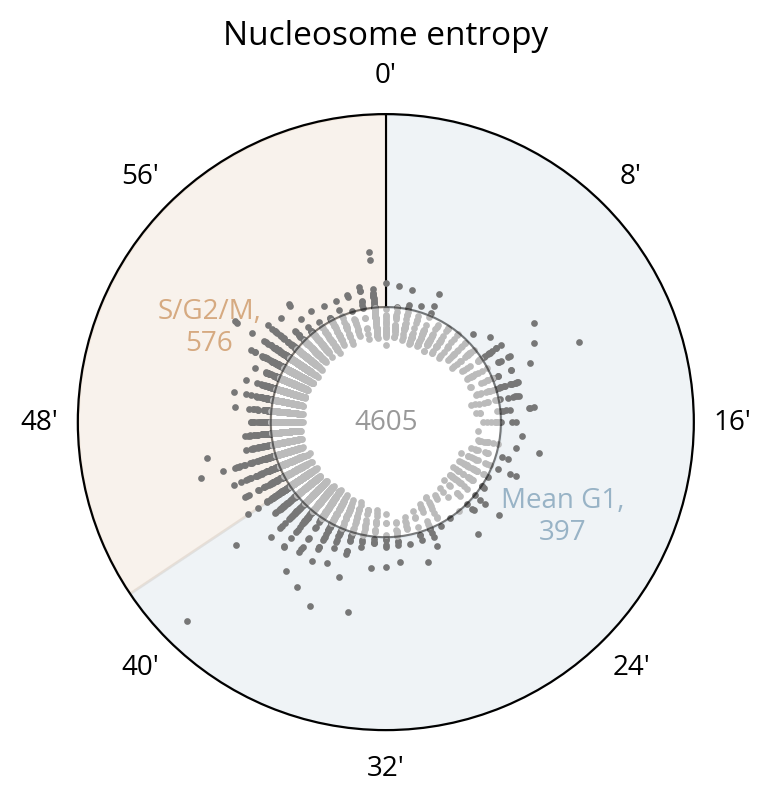

In [150]:
analyzer.plot_polar_branches()

Venn diagrams saved


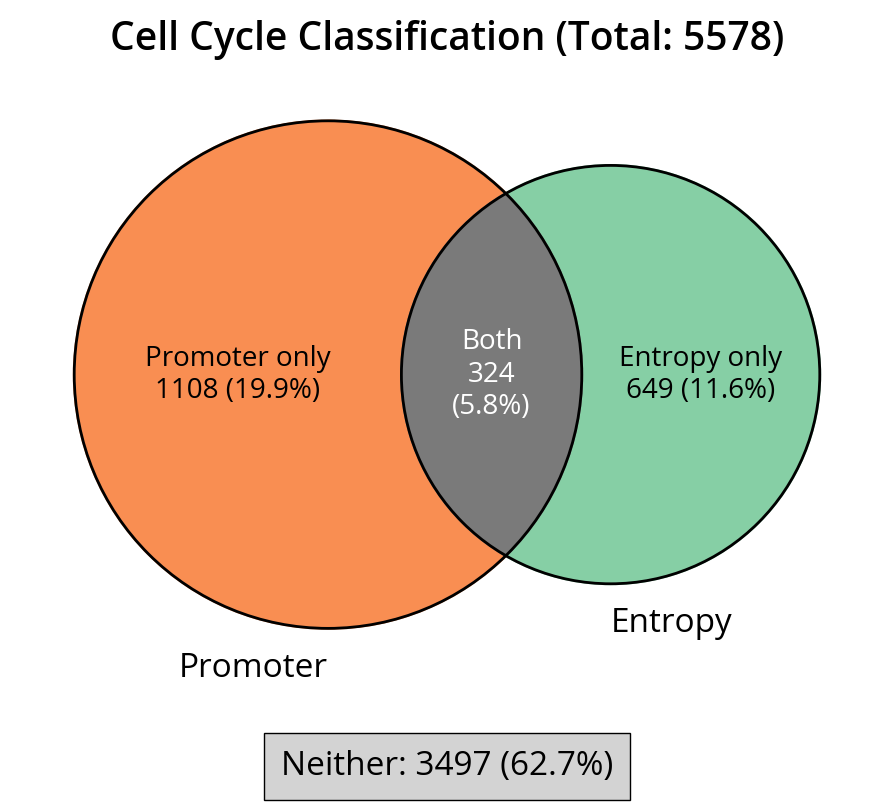

In [139]:
analyzer.plot_venn_diagrams()

In [183]:
plots_dir = f'{output_directory}/genelevel_chromatin/'
save_dir = plots_dir

In [208]:
from pipeline.figure_composer import FigureCompositor

# Define image paths
image_names = [
    'metrics_venn2',
    'promoters_polar',
    'entropy_polar'
]

image_paths = [f"{plots_dir}/{name}.png" for name in image_names]

# Create compositor with a scale factor of 4
# Logical canvas size is 1024x800, but actual output will be 4096x3200
compositor = FigureCompositor(1024, 340, debug_mode=True, scale_factor=4.0)

# Place images individually
# All coordinates and dimensions are specified in logical pixels
# but will be rendered at 4x resolution
margin = 20
venn_width = 320

# -------- Sensitivity analysis -------------
compositor.place_image(image_paths[0], margin, margin, venn_width, None, 'venn')
compositor.add_panel_label_to_image('venn', 'A')

# -------- Polar plots -------------

polar_width = 280
pad_x_polar = 24

polar_x = venn_width+pad_x_polar+margin
img = compositor.place_image(image_paths[1], polar_x, margin, polar_width, 
                      None, 'prom_polar')
compositor.add_panel_label_to_image('prom_polar', 'B')

polar_x = polar_x+polar_width+pad_x_polar
img = compositor.place_image(image_paths[2], polar_x, margin, polar_width, 
                      None, 'entropy_polar')
compositor.add_panel_label_to_image('entropy_polar', 'C')

# Save the figure - will be 4x the logical resolution
compositor.save(f"{save_dir}/Figure_2.png")


Debug figure saved to: output/prototype_pipeline_subset/genelevel_chromatin//Figure_2_debug.png
Clean figure saved to: output/prototype_pipeline_subset/genelevel_chromatin//Figure_2.png


True

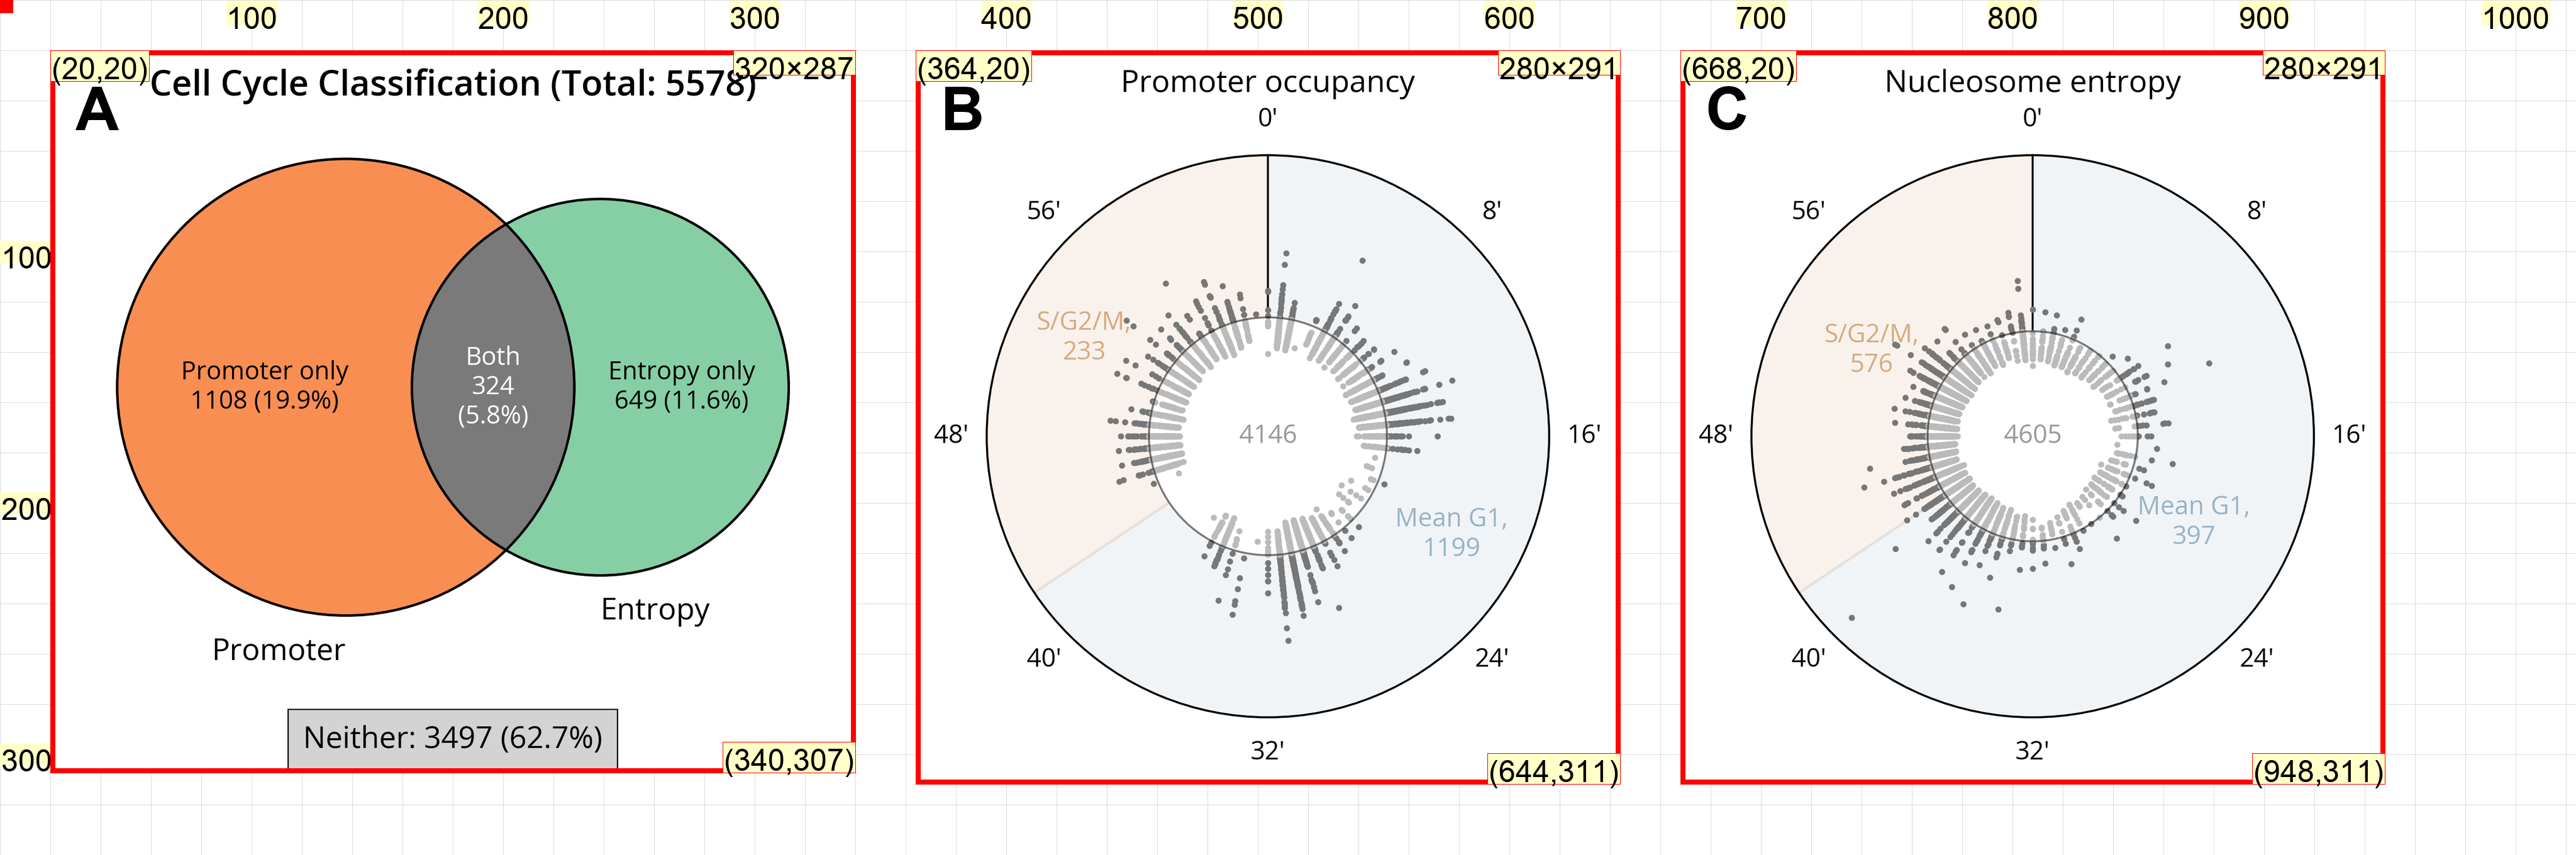

In [209]:
from IPython.display import Image, display
display(Image(f'{plots_dir}/Figure_2_debug.png'))